In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [5]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


(7043, 21)

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes



customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [10]:
df['TotalCharges'].value_counts().head()

TotalCharges
         11
20.2     11
19.75     9
20.05     8
19.9      8
Name: count, dtype: int64

In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [12]:
df['TotalCharges'].isna().sum()

np.int64(11)

<Axes: xlabel='Churn', ylabel='count'>

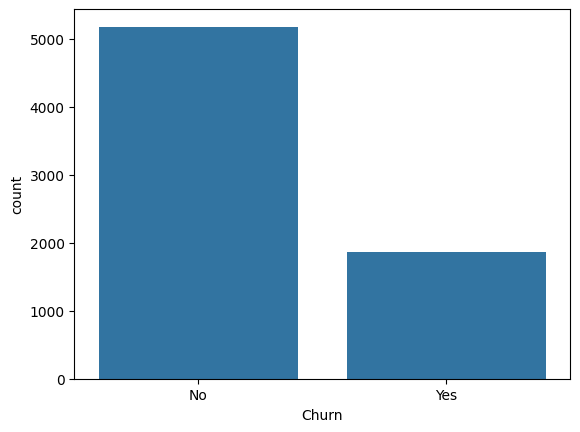

In [13]:
sns.countplot(data = df, x = 'Churn')

<Axes: >

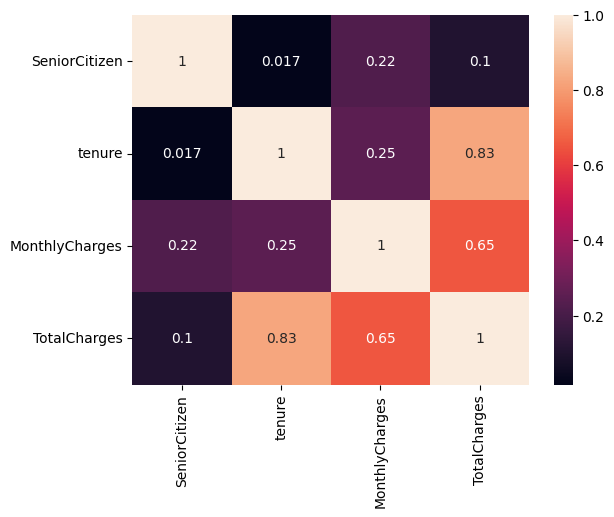

In [14]:
sns.heatmap(df.corr(numeric_only = True), annot = True)

(array([-2000.,     0.,  2000.,  4000.,  6000.,  8000., 10000.]),
 [Text(-2000.0, 0, '−2000'),
  Text(0.0, 0, '0'),
  Text(2000.0, 0, '2000'),
  Text(4000.0, 0, '4000'),
  Text(6000.0, 0, '6000'),
  Text(8000.0, 0, '8000'),
  Text(10000.0, 0, '10000')])

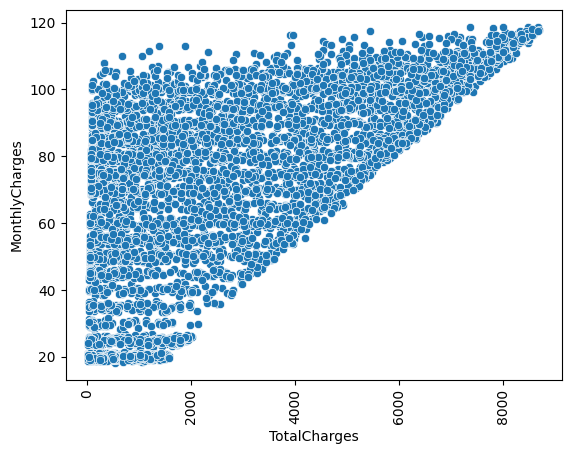

In [15]:
sns.scatterplot(data = df , x = 'TotalCharges', y = 'MonthlyCharges')
plt.xticks(rotation = 90)

(array([-2000.,     0.,  2000.,  4000.,  6000.,  8000., 10000.]),
 [Text(-2000.0, 0, '−2000'),
  Text(0.0, 0, '0'),
  Text(2000.0, 0, '2000'),
  Text(4000.0, 0, '4000'),
  Text(6000.0, 0, '6000'),
  Text(8000.0, 0, '8000'),
  Text(10000.0, 0, '10000')])

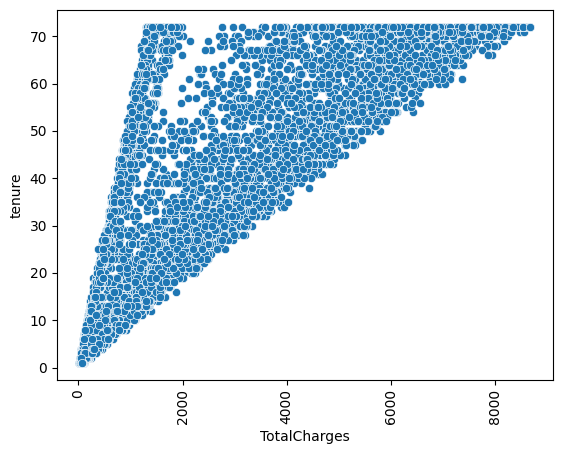

In [16]:
sns.scatterplot(data = df , x = 'TotalCharges', y = 'tenure')
plt.xticks(rotation = 90)

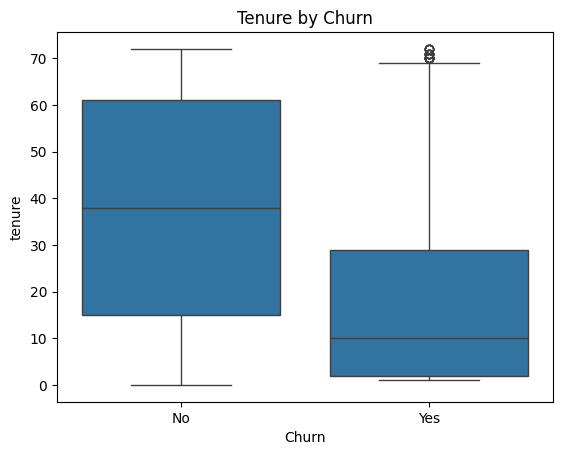

In [17]:
sns.boxplot(data = df , x = 'Churn' , y = 'tenure')
plt.title("Tenure by Churn")
plt.show()

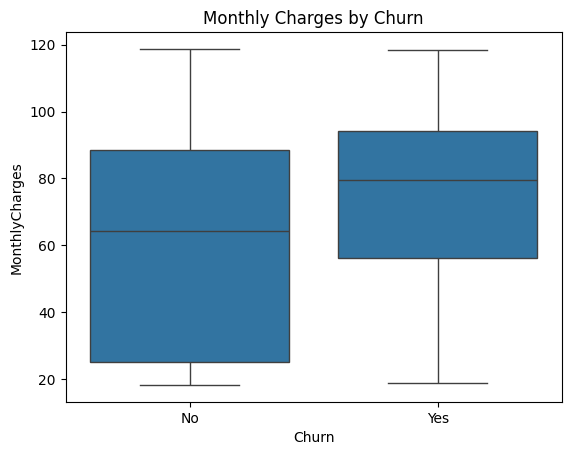

In [18]:
sns.boxplot(data = df , x = 'Churn' , y = 'MonthlyCharges')
plt.title("Monthly Charges by Churn")
plt.show()

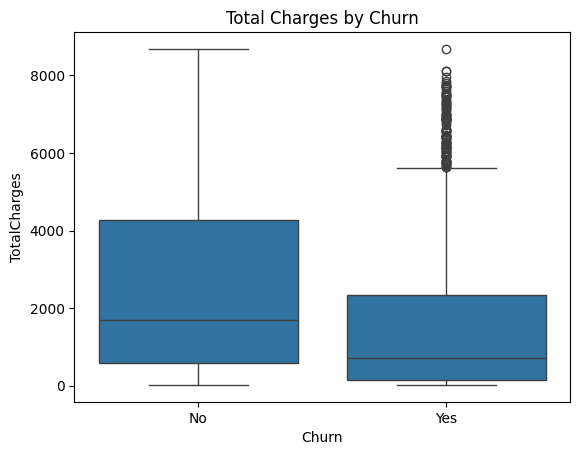

In [19]:
sns.boxplot(data = df , x = 'Churn' , y = 'TotalCharges')
plt.title("Total Charges by Churn")
plt.show()

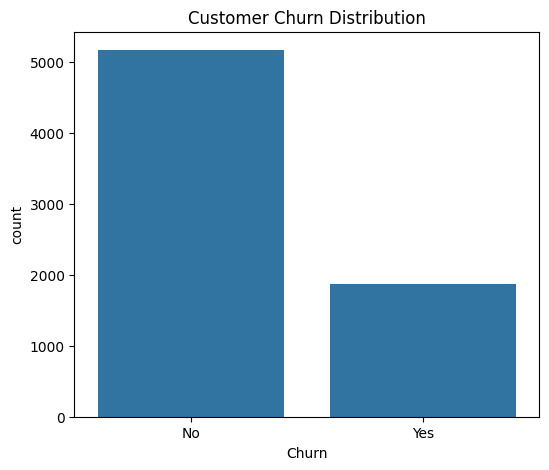

In [20]:
plt.figure(figsize=(6, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.show()

In [21]:
cat_cols = df.select_dtypes(include="object").columns

cat_cols

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

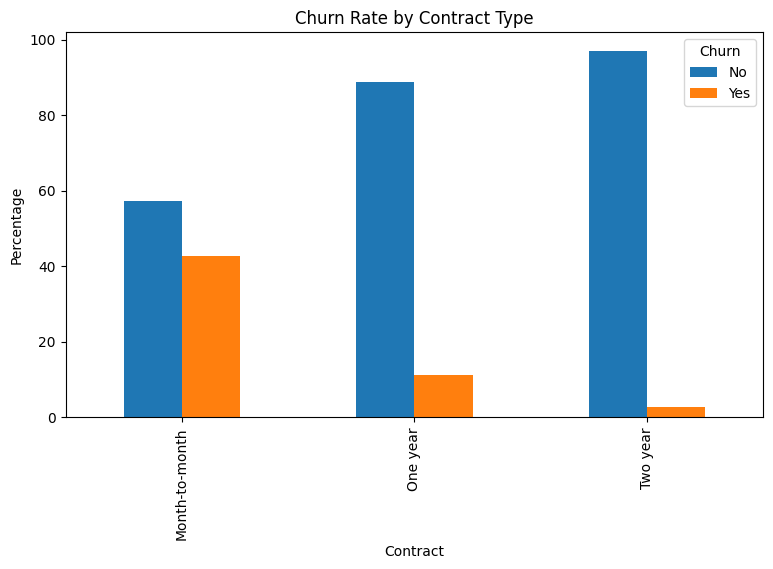

In [22]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
contract_churn.plot(kind="bar",figsize=(9, 5))
plt.ylabel("Percentage")
plt.title("Churn Rate by Contract Type")
plt.xticks(rotation=90)
plt.legend(title="Churn")
plt.show()

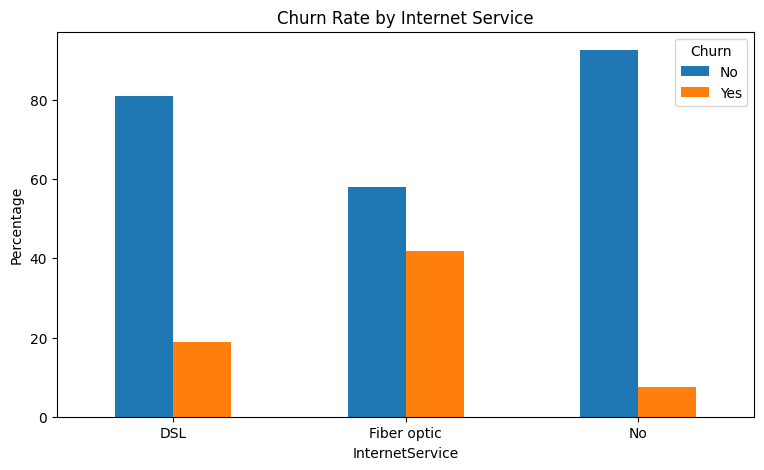

In [23]:
internet_churn = pd.crosstab(df["InternetService"],df["Churn"],normalize="index") * 100

internet_churn.plot(kind="bar",figsize=(9, 5))

plt.ylabel("Percentage")
plt.title("Churn Rate by Internet Service")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

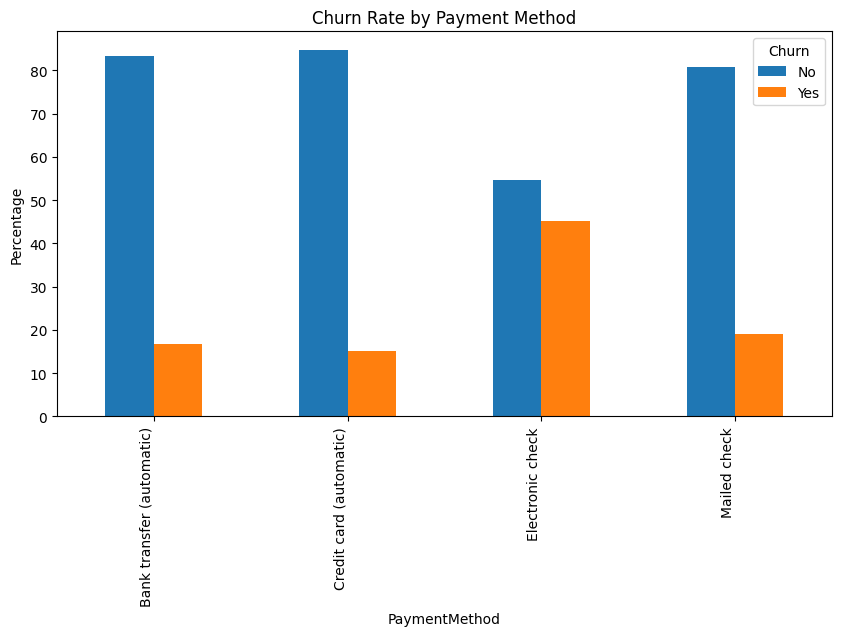

In [24]:
payment_churn = pd.crosstab(df["PaymentMethod"],df["Churn"],normalize="index") * 100

payment_churn.plot(kind="bar",figsize=(10, 5))

plt.ylabel("Percentage")
plt.title("Churn Rate by Payment Method")
plt.xticks(rotation=90, ha="right")
plt.legend(title="Churn")
plt.show()

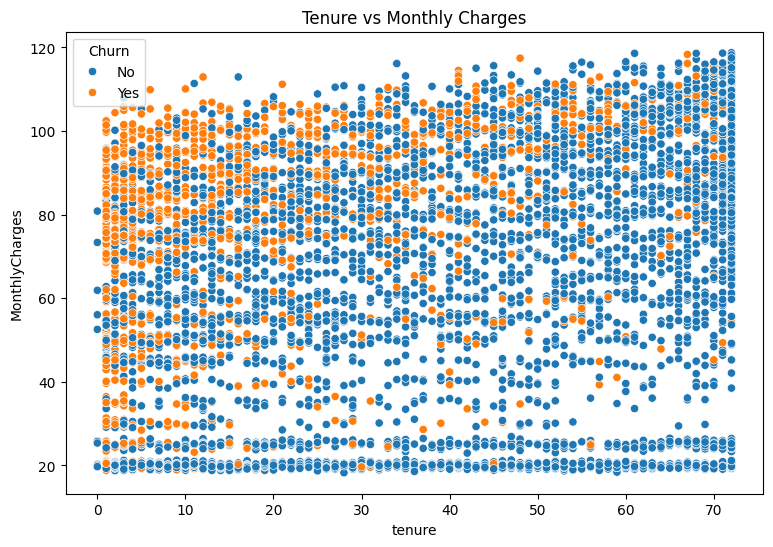

In [25]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="tenure", y="MonthlyCharges",hue="Churn")
plt.title("Tenure vs Monthly Charges")
plt.show()

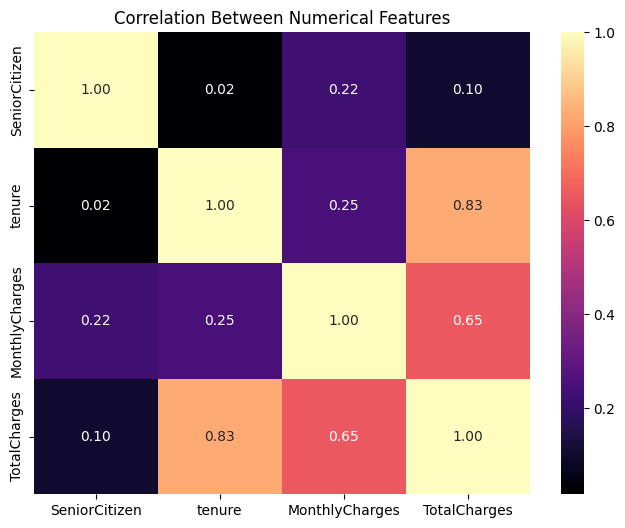

In [26]:
numeric_cols = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="magma",fmt=".2f" )

plt.title("Correlation Between Numerical Features")
plt.show()

In [27]:
#########################   FEATURE ENGINEERING    ##########################
df_ml = df.copy()

In [28]:
df_ml.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [29]:
service_cols = ["PhoneService","MultipleLines","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]

df_ml["NumberOfServices"] = 0
for col in service_cols:
    df_ml["NumberOfServices"] += (
        df_ml[col].isin(["Yes"]).astype(int)
    )

In [30]:
df_ml["NumberOfServices"].value_counts().sort_index()

NumberOfServices
0      80
1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208
Name: count, dtype: int64

In [31]:
df_ml["HasInternet"] = (
    df_ml["InternetService"] != "No"
).astype(int)

In [32]:
df_ml["HasTechSupport"] = (
    df_ml["TechSupport"] == "Yes"
).astype(int)

In [33]:
df_ml["HasOnlineSecurity"] = (
    df_ml["OnlineSecurity"] == "Yes"
).astype(int)

In [34]:
df_ml["AvgMonthlySpend"] = (
    df_ml["TotalCharges"] / df_ml["tenure"].replace(0, 1)
)
df_ml[["tenure", "TotalCharges", "MonthlyCharges", "AvgMonthlySpend"]].head()

,tenure,TotalCharges,MonthlyCharges,AvgMonthlySpend
0,1,29.85,29.85,29.850000
1,34,1889.50,56.95,55.573529
2,2,108.15,53.85,54.075000
3,45,1840.75,42.30,40.905556
4,2,151.65,70.70,75.825000


In [35]:
df_ml["TenureGroup"] = pd.cut(
    df_ml["tenure"],
    bins=[-1, 12, 24, 36, 48, 60, 72],
    labels=["0-12","13-24","25-36","37-48","49-60","61-72"]
)
df_ml["TenureGroup"].value_counts().sort_index()

TenureGroup
0-12     2186
13-24    1024
25-36     832
37-48     762
49-60     832
61-72    1407
Name: count, dtype: int64

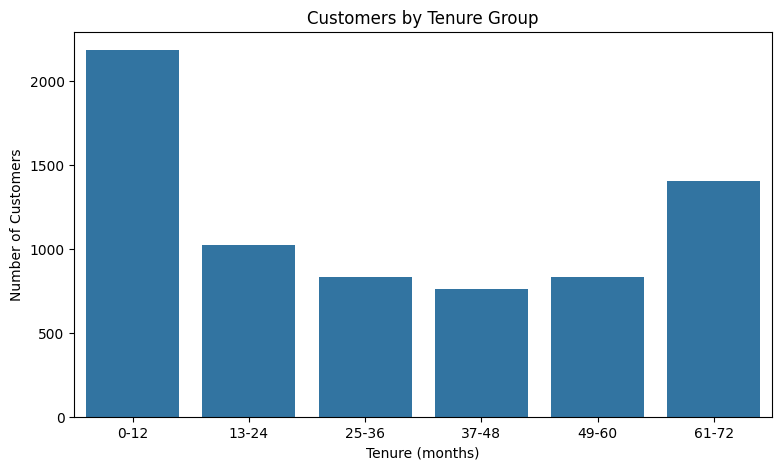

In [36]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df_ml,
    x="TenureGroup",
    order=df_ml["TenureGroup"].cat.categories
)

plt.title("Customers by Tenure Group")
plt.xlabel("Tenure (months)")
plt.ylabel("Number of Customers")
plt.show()

In [37]:
tenure_churn = pd.crosstab(df_ml["TenureGroup"],df_ml["Churn"],normalize="index") * 100
tenure_churn

Churn,No,Yes
TenureGroup,,
0-12,52.561757,47.438243
13-24,71.289062,28.710938
25-36,78.365385,21.634615
37-48,80.971129,19.028871
49-60,85.576923,14.423077
61-72,93.390192,6.609808


In [38]:
df_ml["CustomerValue"] = pd.qcut(df_ml["TotalCharges"],q=3,labels=["Low", "Medium", "High"],duplicates="drop")
pd.crosstab(df_ml["CustomerValue"],df_ml["Churn"],normalize="index") * 100

Churn,No,Yes
CustomerValue,,
Low,60.494881,39.505119
Medium,76.279863,23.720137
High,83.489761,16.510239


In [39]:
############# CUSTOMER SEGMENTATION  ################
cluster_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "NumberOfServices",
    "HasInternet",
    "HasTechSupport",
    "HasOnlineSecurity"
]

X_cluster = df_ml[cluster_features].copy()
X_cluster.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,NumberOfServices,HasInternet,HasTechSupport,HasOnlineSecurity
0,0,1,29.85,29.85,1,1,0,0
1,0,34,56.95,1889.50,3,1,0,1
2,0,2,53.85,108.15,3,1,0,1
3,0,45,42.30,1840.75,3,1,1,1
4,0,2,70.70,151.65,1,1,0,0


In [40]:
X_cluster.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,NumberOfServices,HasInternet,HasTechSupport,HasOnlineSecurity
count,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2283.300441,3.362914,0.783331,0.290217,0.286668
std,0.368612,24.559481,30.090047,2266.771362,2.062031,0.412004,0.453895,0.452237
min,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,401.450000,1.000000,1.000000,0.000000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,3.000000,1.000000,0.000000,0.000000
75%,0.000000,55.000000,89.850000,3794.737500,5.000000,1.000000,1.000000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,8.000000,1.000000,1.000000,1.000000


In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

In [42]:
# Fill missing values with column means
X_cluster = X_cluster.fillna(X_cluster.mean())

# Re-run scaling and KMeans
X_scaled = scaler.fit_transform(X_cluster)

In [43]:

print(np.isnan(X_scaled).sum())
print(np.isinf(X_scaled).sum())

# Fix by dropping or imputing missing values before scaling/fitting
# df = df.dropna() or df = df.fillna(df.mean())

0
0


In [44]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(2,11)
for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

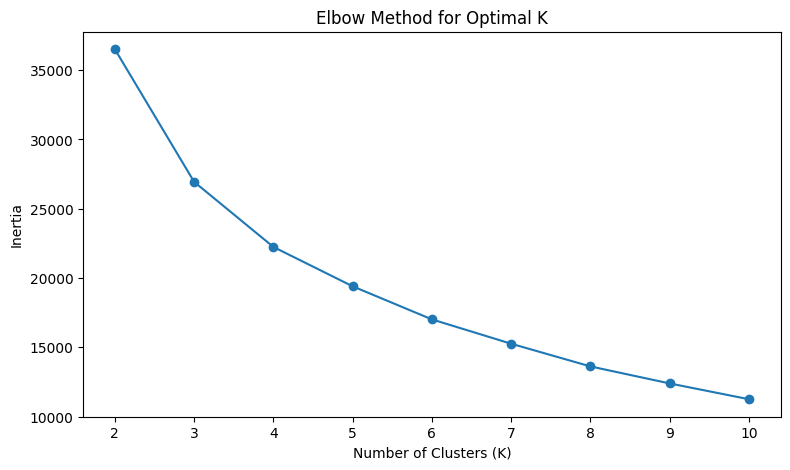

In [45]:
plt.figure(figsize=(9, 5))

plt.plot(K, inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.show()

In [46]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

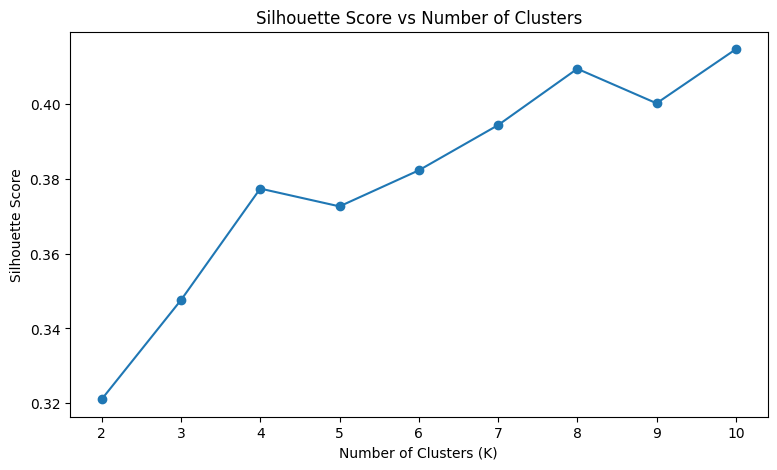

In [47]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")

plt.show()

In [48]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

candidate_k = [4, 8, 10]

for k in candidate_k:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"\n{'='*40}")
    print(f"K = {k}")
    print(f"Silhouette Score = {score:.4f}")
    print("\nCluster Sizes:")
    print(pd.Series(labels).value_counts().sort_index())


K = 4
Silhouette Score = 0.3774

Cluster Sizes:
0    2624
1     916
2    1977
3    1526
Name: count, dtype: int64

K = 8
Silhouette Score = 0.4095

Cluster Sizes:
0     437
1    1486
2     865
3    1526
4     601
5     689
6     653
7     786
Name: count, dtype: int64

K = 10
Silhouette Score = 0.4147

Cluster Sizes:
0    1347
1     535
2     854
3     882
4     622
5     648
6     463
7     616
8     432
9     644
Name: count, dtype: int64


In [49]:
final_kmeans = KMeans(
    n_clusters=8,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

df_ml["Cluster"] = cluster_labels
df_ml["Cluster"].value_counts().sort_index()

Cluster
0     437
1    1486
2     865
3    1526
4     601
5     689
6     653
7     786
Name: count, dtype: int64

In [50]:
profile_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "NumberOfServices",
    "HasInternet",
    "HasTechSupport",
    "HasOnlineSecurity"
]

cluster_profile = df_ml.groupby("Cluster")[profile_cols].mean().round(2)
cluster_profile

,tenure,MonthlyCharges,TotalCharges,NumberOfServices,HasInternet,HasTechSupport,HasOnlineSecurity
Cluster,,,,,,,
0,56.19,94.61,5314.02,5.58,1.0,0.50,0.48
1,12.19,67.18,809.99,2.28,1.0,0.00,0.00
2,62.66,91.29,5716.71,6.44,1.0,1.00,0.76
3,30.55,21.08,665.22,1.22,0.0,0.00,0.00
4,27.06,70.96,1923.38,3.88,1.0,1.00,0.00
5,55.07,91.22,4995.86,4.88,1.0,0.00,0.43
6,17.35,74.53,1284.60,2.83,1.0,0.07,0.11
7,24.14,63.16,1456.76,3.68,1.0,0.40,1.00


In [51]:
pd.crosstab(df_ml["Cluster"],df_ml["Churn"],normalize="index").round(3) * 100

Churn,No,Yes
Cluster,,
0,77.3,22.7
1,48.5,51.5
2,91.9,8.1
3,92.6,7.4
4,75.7,24.3
5,78.7,21.3
6,43.0,57.0
7,80.2,19.8


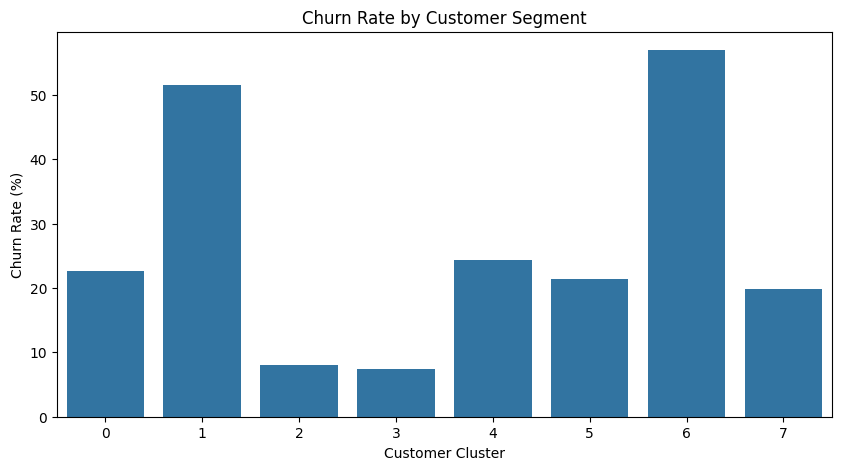

In [52]:
#######  VISUALS  ######

cluster_churn = (
    pd.crosstab(
        df_ml["Cluster"],
        df_ml["Churn"],
        normalize="index"
    )["Yes"] * 100
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=cluster_churn.index,
    y=cluster_churn.values
)

plt.xlabel("Customer Cluster")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Customer Segment")

plt.show()

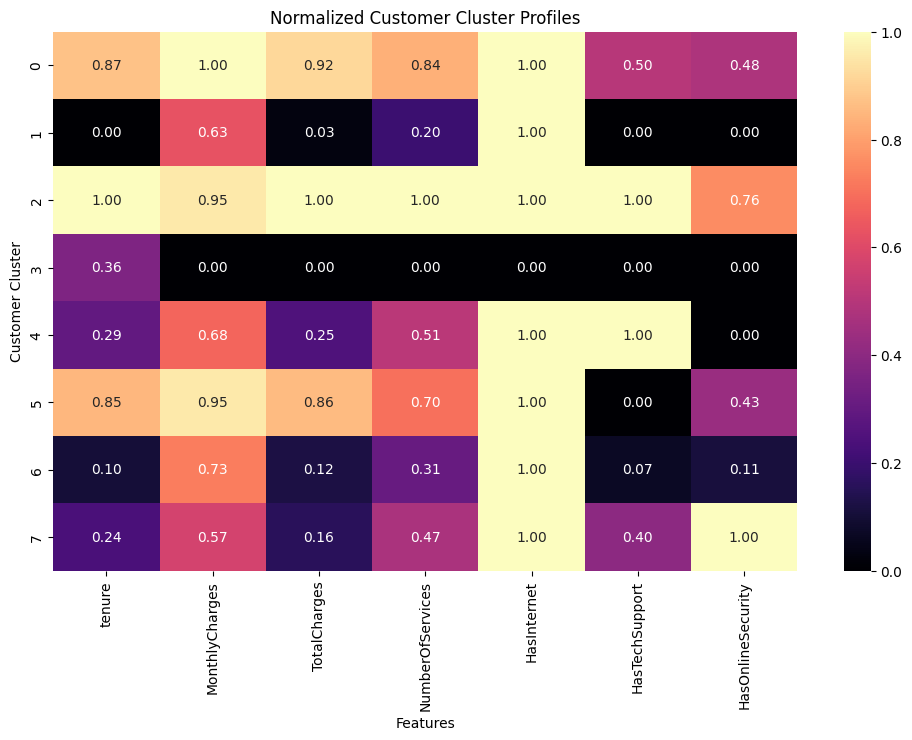

In [53]:
from sklearn.preprocessing import MinMaxScaler

profile_scaled = pd.DataFrame(
    MinMaxScaler().fit_transform(cluster_profile),
    columns=cluster_profile.columns,
    index=cluster_profile.index
)

plt.figure(figsize=(12, 7))

sns.heatmap(
    profile_scaled,
    annot=True,
    fmt=".2f",
    cmap="magma"
)

plt.title("Normalized Customer Cluster Profiles")
plt.xlabel("Features")
plt.ylabel("Customer Cluster")

plt.show()

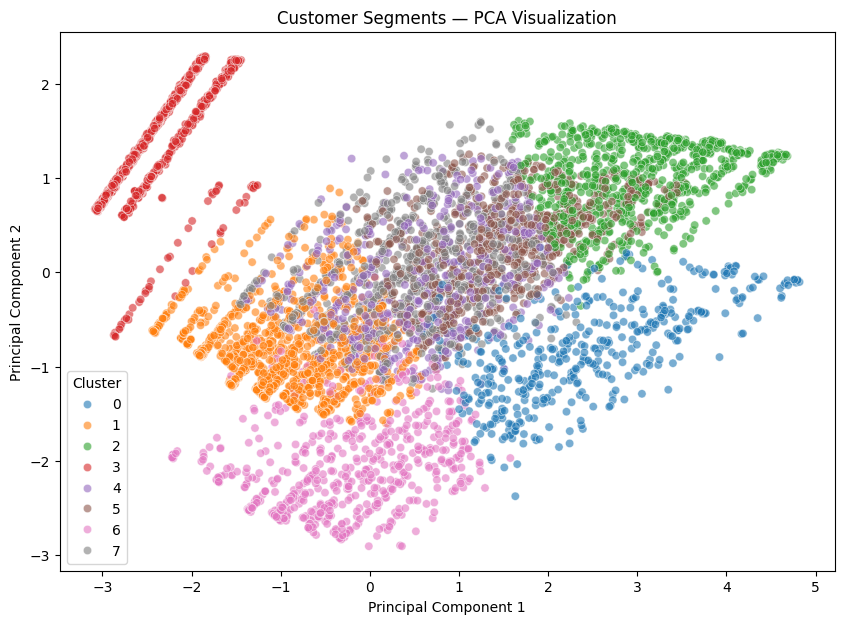

In [54]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df_ml["PCA1"] = X_pca[:, 0]
df_ml["PCA2"] = X_pca[:, 1]

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_ml,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="tab10",
    alpha=0.6
)

plt.title("Customer Segments — PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

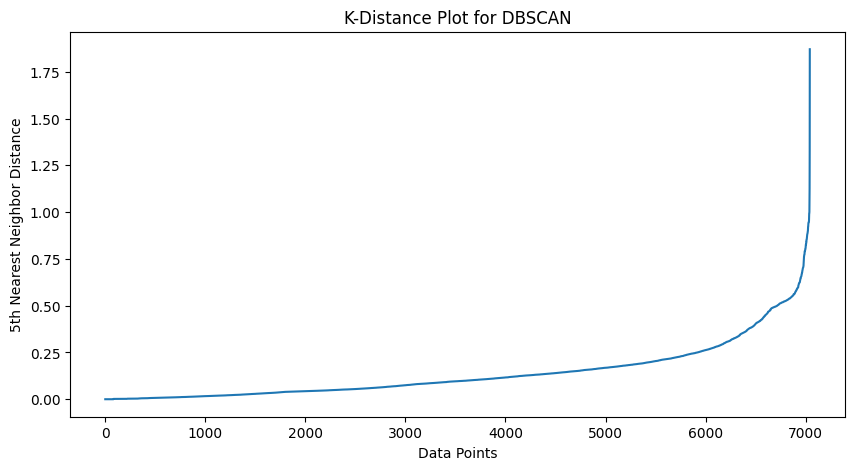

In [55]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 4])

plt.figure(figsize=(10, 5))

plt.plot(distances)

plt.xlabel("Data Points")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("K-Distance Plot for DBSCAN")

plt.show()

In [56]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.6,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

cluster_counts = pd.Series(dbscan_labels).value_counts().sort_index()

print(cluster_counts)

-1       66
 0     1882
 1      760
 2      973
 3      806
 4     1468
 5      118
 6      102
 7      546
 8       95
 9      113
 10      52
 11      27
 12      16
 13       6
 14       9
 15       4
Name: count, dtype: int64


In [57]:
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)
print("Noise percentage:", round(n_noise / len(dbscan_labels) * 100, 2), "%")

Number of clusters: 16
Number of noise points: 66
Noise percentage: 0.94 %


In [58]:
mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) >= 2:
    score = silhouette_score(
        X_scaled[mask],
        dbscan_labels[mask]
    )
    print("DBSCAN Silhouette Score:", round(score, 4))
else:
    print("Not enough clusters for silhouette score.")

DBSCAN Silhouette Score: 0.2756


In [59]:
################# SUPERVISED LEARNING  #################
y = df_ml["Churn"]

In [60]:
X = df_ml.drop(
    columns=["Churn", "Cluster", "PCA1", "PCA2"],
    errors="ignore"
)

y = df_ml["Churn"]

In [61]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (7043, 27)
y shape: (7043,)

Target distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [62]:
X = X.drop(columns=["customerID"])

In [63]:
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup', 'CustomerValue']

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'NumberOfServices', 'HasInternet', 'HasTechSupport', 'HasOnlineSecurity', 'AvgMonthlySpend']


In [64]:
df_ml["CustomerValue"] = pd.qcut(
    df_ml["TotalCharges"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [65]:
X = X.drop(columns=["CustomerValue"], errors="ignore")

In [66]:
X = X.drop(
    columns=["HasTechSupport", "HasOnlineSecurity"],
    errors="ignore"
)

In [67]:
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical:")
print(categorical_features)

print("\nNumerical:")
print(numerical_features)

Categorical:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']

Numerical:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'NumberOfServices', 'HasInternet', 'AvgMonthlySpend']


In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 23)
X_test : (1409, 23)
y_train: (5634,)
y_test : (1409,)


In [69]:
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'NumberOfServices', 'HasInternet', 'AvgMonthlySpend']


In [70]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

In [71]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [72]:
print(X_train.shape)
print(X_test.shape)

print("\nMissing values:")
print(X_train.isna().sum()[X_train.isna().sum() > 0])

print("\nData types:")
print(X_train.dtypes)

(5634, 23)
(1409, 23)

Missing values:
TotalCharges       8
AvgMonthlySpend    8
dtype: int64

Data types:
gender                object
SeniorCitizen          int64
Partner               object
Dependents            object
tenure                 int64
PhoneService          object
MultipleLines         object
InternetService       object
OnlineSecurity        object
OnlineBackup          object
DeviceProtection      object
TechSupport           object
StreamingTV           object
StreamingMovies       object
Contract              object
PaperlessBilling      object
PaymentMethod         object
MonthlyCharges       float64
TotalCharges         float64
NumberOfServices       int64
HasInternet            int64
AvgMonthlySpend      float64
TenureGroup         category
dtype: object


In [73]:
print("Categorical:")
print(categorical_features)

print("\nNumerical:")
print(numerical_features)

print("\nAll features accounted for:",
      set(categorical_features + numerical_features) == set(X_train.columns))

Categorical:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']

Numerical:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'NumberOfServices', 'HasInternet', 'AvgMonthlySpend']

All features accounted for: True


In [74]:
nan_counts = X_train.isna().sum()

print(nan_counts[nan_counts > 0])

TotalCharges       8
AvgMonthlySpend    8
dtype: int64


In [75]:
X_train[X_train.isna().any(axis=1)]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,NumberOfServices,HasInternet,AvgMonthlySpend,TenureGroup
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,...,No,Two year,No,Mailed check,73.35,NaN,6,1,NaN,0-12
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,Two year,No,Mailed check,20.00,NaN,1,0,NaN,0-12
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,Two year,No,Mailed check,25.35,NaN,2,0,NaN,0-12
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,...,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,4,1,NaN,0-12
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,Two year,No,Mailed check,25.75,NaN,2,0,NaN,0-12
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,...,No,Two year,No,Credit card (automatic),56.05,NaN,5,1,NaN,0-12
6754,Male,0,No,Yes,0,Yes,Yes,DSL,Yes,Yes,...,No,Two year,Yes,Bank transfer (automatic),61.90,NaN,5,1,NaN,0-12
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,Two year,No,Mailed check,19.85,NaN,1,0,NaN,0-12


In [76]:
df_ml["AvgMonthlySpend"] = (
    df_ml["TotalCharges"] / df_ml["tenure"].replace(0, 1)
)

In [77]:
print("TotalCharges NaN:", df_ml["TotalCharges"].isna().sum())
print("AvgMonthlySpend NaN:", df_ml["AvgMonthlySpend"].isna().sum())
print("Tenure NaN:", df_ml["tenure"].isna().sum())

TotalCharges NaN: 11
AvgMonthlySpend NaN: 11
Tenure NaN: 0


In [78]:
df_ml["AvgMonthlySpend"] = (
    df_ml["TotalCharges"] /
    df_ml["tenure"].replace(0, 1)
)

df_ml["AvgMonthlySpend"] = df_ml["AvgMonthlySpend"].fillna(0)

In [79]:
X = df_ml.drop(
    columns=["Churn", "Cluster", "PCA1", "PCA2", "CustomerValue"],
    errors="ignore"
)

X = X.drop(
    columns=["customerID", "HasTechSupport", "HasOnlineSecurity"],
    errors="ignore"
)

In [80]:
print(X.isna().sum()[X.isna().sum() > 0])

TotalCharges    11
dtype: int64


In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [82]:
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

In [83]:
df_ml["TotalCharges"] = df_ml["TotalCharges"].fillna(0)

print("TotalCharges NaN:", df_ml["TotalCharges"].isna().sum())

TotalCharges NaN: 0


In [84]:
df_ml["AvgMonthlySpend"] = (
    df_ml["TotalCharges"] /
    df_ml["tenure"].replace(0, 1)
)

df_ml["AvgMonthlySpend"] = df_ml["AvgMonthlySpend"].fillna(0)

In [85]:
print("AvgMonthlySpend NaN:", df_ml["AvgMonthlySpend"].isna().sum())

AvgMonthlySpend NaN: 0


In [86]:
X = df_ml.drop(
    columns=["Churn", "Cluster", "PCA1", "PCA2", "CustomerValue"],
    errors="ignore"
)

X = X.drop(
    columns=["customerID", "HasTechSupport", "HasOnlineSecurity"],
    errors="ignore"
)

In [87]:
missing = X.isna().sum()

print(missing[missing > 0])

Series([], dtype: int64)


In [88]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [89]:
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

In [90]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

In [91]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [92]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'NumberOfServices',
                                                   'HasInternet',
                                                   'AvgMonthlySpend']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'TenureGroup'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [93]:
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [94]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [95]:
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred, pos_label="Yes"), 4))
print("Recall   :", round(recall_score(y_test, y_pred, pos_label="Yes"), 4))
print("F1 Score :", round(f1_score(y_test, y_pred, pos_label="Yes"), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

Accuracy : 0.8027
Precision: 0.6611
Recall   : 0.5267
F1 Score : 0.5863
ROC-AUC  : 0.8428


In [96]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1035
         Yes       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [97]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[934 101]
 [177 197]]


In [98]:
y = df_ml["Churn"].map({
    "No": 0,
    "Yes": 1
})

print(y.value_counts())
print(y.value_counts(normalize=True))

Churn
0    5174
1    1869
Name: count, dtype: int64
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [100]:
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

In [101]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

In [102]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [103]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'NumberOfServices',
                                                   'HasInternet',
                                                   'AvgMonthlySpend']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'TenureGroup'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [104]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

def evaluate_model(name, model):
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }
    
    results.append(metrics)
    
    return metrics

In [105]:
evaluate_model("Logistic Regression", logistic_model)

{'Model': 'Logistic Regression',
 'Accuracy': 0.8026969481902059,
 'Precision': 0.6610738255033557,
 'Recall': 0.5267379679144385,
 'F1': 0.5863095238095238,
 'ROC-AUC': np.float64(0.8427729985274742)}

In [106]:

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.802697,0.661074,0.526738,0.58631,0.842773


In [107]:
from sklearn.tree import DecisionTreeClassifier

In [108]:
decision_tree = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

In [109]:
decision_tree.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'NumberOfServices',
                                                   'HasInternet',
                                                   'AvgMonthlySpend']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'TenureGroup'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [110]:
evaluate_model(
    "Decision Tree",
    decision_tree
)

{'Model': 'Decision Tree',
 'Accuracy': 0.7494677075940384,
 'Precision': 0.5283018867924528,
 'Recall': 0.5240641711229946,
 'F1': 0.5261744966442953,
 'ROC-AUC': np.float64(0.6770311813790073)}

In [111]:
pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.802697,0.661074,0.526738,0.586310,0.842773
1,Decision Tree,0.749468,0.528302,0.524064,0.526174,0.677031


In [112]:
from sklearn.ensemble import RandomForestClassifier

random_forest = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [113]:
random_forest.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'NumberOfServices',
                                                   'HasInternet',
                                                   'AvgMonthlySpend']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'TenureGroup'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [114]:
evaluate_model(
    "Random Forest",
    random_forest
)

{'Model': 'Random Forest',
 'Accuracy': 0.78708303761533,
 'Precision': 0.6217105263157895,
 'Recall': 0.5053475935828877,
 'F1': 0.5575221238938053,
 'ROC-AUC': np.float64(0.8229326513213983)}

In [115]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.802697,0.661074,0.526738,0.586310,0.842773
1,Decision Tree,0.749468,0.528302,0.524064,0.526174,0.677031
2,Random Forest,0.787083,0.621711,0.505348,0.557522,0.822933


In [116]:
from sklearn.svm import SVC

svm_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            SVC(
                kernel="rbf",
                probability=True,
                random_state=42
            )
        )
    ]
)

svm_model.fit(X_train, y_train)

evaluate_model(
    "SVM",
    svm_model
)

{'Model': 'SVM',
 'Accuracy': 0.7856635911994322,
 'Precision': 0.6428571428571429,
 'Recall': 0.43315508021390375,
 'F1': 0.5175718849840255,
 'ROC-AUC': np.float64(0.7964711049110026)}

In [117]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.802697,0.661074,0.526738,0.586310,0.842773
1,Decision Tree,0.749468,0.528302,0.524064,0.526174,0.677031
2,Random Forest,0.787083,0.621711,0.505348,0.557522,0.822933
3,SVM,0.785664,0.642857,0.433155,0.517572,0.796471


In [118]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

gradient_boosting.fit(X_train, y_train)

evaluate_model(
    "Gradient Boosting",
    gradient_boosting
)

{'Model': 'Gradient Boosting',
 'Accuracy': 0.801277501774308,
 'Precision': 0.6666666666666666,
 'Recall': 0.5026737967914439,
 'F1': 0.573170731707317,
 'ROC-AUC': np.float64(0.8427174558888113)}

In [119]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.802697,0.661074,0.526738,0.586310,0.842773
4,Gradient Boosting,0.801278,0.666667,0.502674,0.573171,0.842717
2,Random Forest,0.787083,0.621711,0.505348,0.557522,0.822933
3,SVM,0.785664,0.642857,0.433155,0.517572,0.796471
1,Decision Tree,0.749468,0.528302,0.524064,0.526174,0.677031


In [120]:
import xgboost

from xgboost import XGBClassifier


In [121]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

xgb_model.fit(X_train, y_train)

evaluate_model(
    "XGBoost",
    xgb_model
)

{'Model': 'XGBoost',
 'Accuracy': 0.8019872249822569,
 'Precision': 0.6567656765676567,
 'Recall': 0.5320855614973262,
 'F1': 0.5878877400295421,
 'ROC-AUC': np.float64(0.8452737089565734)}

In [122]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
5,XGBoost,0.801987,0.656766,0.532086,0.587888,0.845274
0,Logistic Regression,0.802697,0.661074,0.526738,0.586310,0.842773
4,Gradient Boosting,0.801278,0.666667,0.502674,0.573171,0.842717
2,Random Forest,0.787083,0.621711,0.505348,0.557522,0.822933
3,SVM,0.785664,0.642857,0.433155,0.517572,0.796471
1,Decision Tree,0.749468,0.528302,0.524064,0.526174,0.677031


In [123]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [124]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [125]:
cv_results = cross_validate(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [126]:
for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    
    print(
        f"{metric.upper():10s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

ACCURACY  : 0.8025 ± 0.0091
PRECISION : 0.6633 ± 0.0276
RECALL    : 0.5211 ± 0.0197
F1        : 0.5833 ± 0.0174
ROC_AUC   : 0.8458 ± 0.0114


In [127]:
####### HYPERPARAMETER TUNING  ###########

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "classifier__n_estimators": [100, 200, 300, 400],
    "classifier__max_depth": [2, 3, 4, 5, 6],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.15],
    "classifier__subsample": [0.7, 0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "classifier__min_child_weight": [1, 3, 5, 7],
    "classifier__gamma": [0, 0.1, 0.3, 0.5]
}

In [128]:
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [129]:
random_search.fit(X_train, y_train)


Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['SeniorCitizen',
                                                                                'tenure',
                                                                                'MonthlyCharges',
                                                                                'TotalCharges',
                                                                                'NumberOfServices',
                                                                                'HasInternet',
                                                                                'AvgMonthlySpend']),
                                                                              ('cat',
                                                                               OneHotEncoder(drop='first',
                                                                                             handle_unknown='ignore'),
                                                                               ['g...
                   param_distributions={'classifier__colsample_bytree': [0.7,
                                                                         0.8,
                                                                         0.9,
                                                                         1.0],
                                        'classifier__gamma': [0, 0.1, 0.3, 0.5],
                                        'classifier__learning_rate': [0.01,
                                                                      0.03,
                                                                      0.05, 0.1,
                                                                      0.15],
                                        'classifier__max_depth': [2, 3, 4, 5,
                                                                  6],
                                        'classifier__min_child_weight': [1, 3,
                                                                         5, 7],
                                        'classifier__n_estimators': [100, 200,
                                                                     300, 400],
                                        'classifier__subsample': [0.7, 0.8, 0.9,
                                                                  1.0]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [130]:
print("Best ROC-AUC:", random_search.best_score_)

Best ROC-AUC: 0.8491368221370303


In [131]:
print("\nBest Parameters:")

for param, value in random_search.best_params_.items():
    print(f"{param}: {value}")


Best Parameters:
classifier__subsample: 0.8
classifier__n_estimators: 100
classifier__min_child_weight: 1
classifier__max_depth: 4
classifier__learning_rate: 0.05
classifier__gamma: 0
classifier__colsample_bytree: 0.7


In [132]:
best_xgb = random_search.best_estimator_

In [133]:
tuned_pred = best_xgb.predict(X_test)
tuned_prob = best_xgb.predict_proba(X_test)[:, 1]

In [134]:
print("Accuracy :", round(accuracy_score(y_test, tuned_pred), 4))
print("Precision:", round(precision_score(y_test, tuned_pred), 4))
print("Recall   :", round(recall_score(y_test, tuned_pred), 4))
print("F1 Score :", round(f1_score(y_test, tuned_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, tuned_prob), 4))

Accuracy : 0.7999
Precision: 0.6575
Recall   : 0.5134
F1 Score : 0.5766
ROC-AUC  : 0.847


In [135]:
from sklearn.model_selection import cross_val_predict

oof_prob = cross_val_predict(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [136]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.20, 0.71, 0.05)

threshold_results = []

for threshold in thresholds:
    
    predictions = (oof_prob >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_train,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_train,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_train,
            predictions,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(3)

,Threshold,Precision,Recall,F1
0,0.20,0.482,0.851,0.615
1,0.25,0.514,0.807,0.628
2,0.30,0.543,0.757,0.632
3,0.35,0.570,0.706,0.630
4,0.40,0.607,0.641,0.624
5,0.45,0.641,0.575,0.606
6,0.50,0.662,0.521,0.583
7,0.55,0.687,0.458,0.550
8,0.60,0.711,0.389,0.503
9,0.65,0.733,0.318,0.444


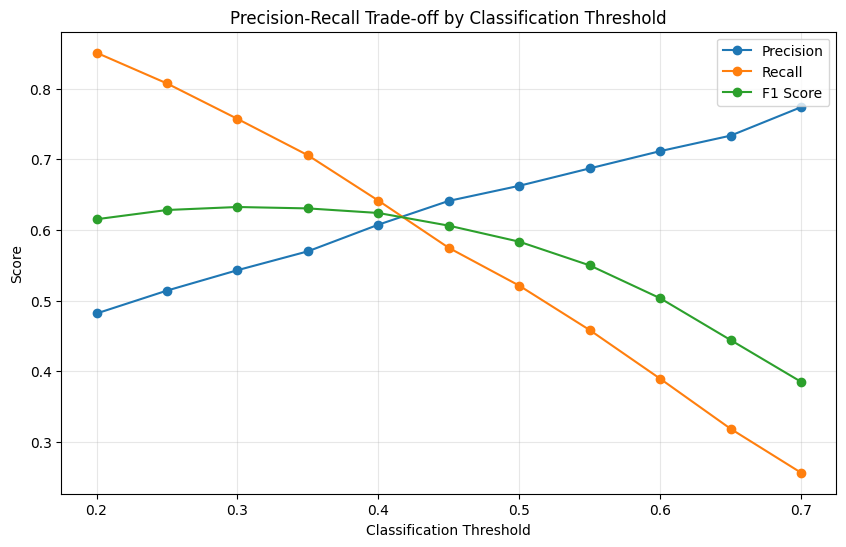

In [137]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Trade-off by Classification Threshold")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [138]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print(best_threshold_row)

Threshold    0.300000
Precision    0.542926
Recall       0.757191
F1           0.632402
Name: 2, dtype: float64


In [139]:
best_threshold = best_threshold_row["Threshold"]

print("Selected threshold:", best_threshold)

Selected threshold: 0.3


In [140]:
final_prob = xgb_model.predict_proba(X_test)[:, 1]


In [141]:
final_pred = (
    final_prob >= best_threshold
).astype(int)

In [142]:
print(
    "Accuracy :",
    round(accuracy_score(y_test, final_pred), 4)
)

print(
    "Precision:",
    round(precision_score(y_test, final_pred), 4)
)

print(
    "Recall   :",
    round(recall_score(y_test, final_pred), 4)
)

print(
    "F1 Score :",
    round(f1_score(y_test, final_pred), 4)
)

print(
    "ROC-AUC  :",
    round(roc_auc_score(y_test, final_prob), 4)
)

Accuracy : 0.7509
Precision: 0.5208
Recall   : 0.7701
F1 Score : 0.6214
ROC-AUC  : 0.8453


In [143]:
###### FINAL EVALUATION  ########

final_prob = xgb_model.predict_proba(X_test)[:, 1]

In [144]:
final_pred = (
    final_prob >= best_threshold
).astype(int)

In [145]:
print("FINAL MODEL — THRESHOLD 0.30")
print("--------------------------------")

print("Accuracy :", round(
    accuracy_score(y_test, final_pred), 4
))

print("Precision:", round(
    precision_score(y_test, final_pred), 4
))

print("Recall   :", round(
    recall_score(y_test, final_pred), 4
))

print("F1 Score :", round(
    f1_score(y_test, final_pred), 4
))

print("ROC-AUC  :", round(
    roc_auc_score(y_test, final_prob), 4
))

FINAL MODEL — THRESHOLD 0.30
--------------------------------
Accuracy : 0.7509
Precision: 0.5208
Recall   : 0.7701
F1 Score : 0.6214
ROC-AUC  : 0.8453


In [146]:
print(classification_report(
    y_test,
    final_pred,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.90      0.74      0.81      1035
       Churn       0.52      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



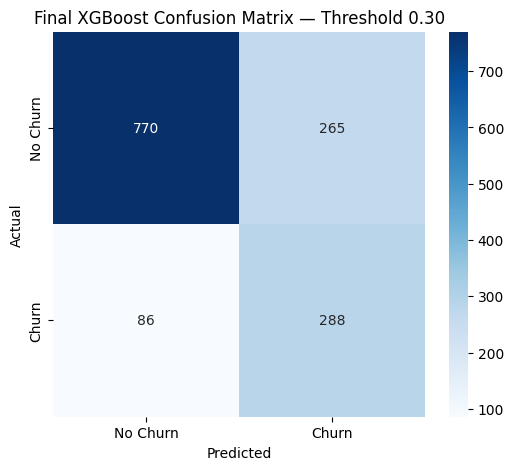

In [147]:
cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final XGBoost Confusion Matrix — Threshold 0.30")

plt.show()

In [148]:
import joblib

joblib.dump(
    xgb_model,
    "churn_model.pkl"
)

['churn_model.pkl']

In [149]:
joblib.dump(
    best_threshold,
    "churn_threshold.pkl"
)

['churn_threshold.pkl']

In [150]:
joblib.dump(
    final_kmeans,
    "kmeans_model.pkl"
)

['kmeans_model.pkl']

In [151]:
joblib.dump(
    scaler,
    "cluster_scaler.pkl"
)

['cluster_scaler.pkl']

In [152]:
import joblib

joblib.dump(
    xgb_model,
    "churn_model.pkl"
)

['churn_model.pkl']

In [153]:
joblib.dump(
    best_threshold,
    "churn_threshold.pkl"
)

['churn_threshold.pkl']

In [154]:
joblib.dump(
    final_kmeans,
    "kmeans_model.pkl"
)

['kmeans_model.pkl']

In [155]:
joblib.dump(
    scaler,
    "cluster_scaler.pkl"
)

['cluster_scaler.pkl']

In [157]:
[name for name in dir() if "scal" in name.lower()]

['MinMaxScaler', 'StandardScaler', 'X_scaled', 'profile_scaled', 'scaler']

In [158]:
import os

os.makedirs("models", exist_ok=True)

print("Models folder created.")

Models folder created.


In [159]:
import joblib

joblib.dump(
    xgb_model,
    "models/churn_model.pkl"
)

print("Churn model saved.")

Churn model saved.


In [160]:
joblib.dump(
    best_threshold,
    "models/churn_threshold.pkl"
)

print("Threshold saved:", best_threshold)

Threshold saved: 0.3


In [161]:
joblib.dump(
    final_kmeans,
    "models/kmeans_model.pkl"
)

print("K-Means model saved.")

K-Means model saved.


In [162]:
joblib.dump(
    scaler,
    "models/cluster_scaler.pkl"
)

print("Cluster scaler saved.")

Cluster scaler saved.


In [163]:
cluster_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "NumberOfServices",
    "HasInternet",
    "HasTechSupport",
    "HasOnlineSecurity"
]

In [164]:
joblib.dump(
    cluster_features,
    "models/cluster_features.pkl"
)

print("Cluster feature list saved.")

Cluster feature list saved.


In [166]:
results_df.to_csv(
    "models/model_comparison.csv",
    index=False
)

In [167]:
threshold_df.to_csv(
    "models/threshold_analysis.csv",
    index=False
)

In [168]:
cluster_profile.to_csv(
    "models/cluster_profile.csv"
)